In [1]:
from src.config import RAW_DATA_DIR
from src.data.loader import load_meld
from src.models.baselines import MajorityClassifier
from src.evaluation.metrics import evaluate, print_results, plot_confusion_matrix

In [2]:
from src.evaluation.results import (
    save_metrics,
    save_metadata,
    save_confusion_matrix,
)

In [3]:
meld = load_meld(RAW_DATA_DIR / "meld")

In [4]:
model = MajorityClassifier()

model.fit(
    meld.train["text"],
    meld.train["emotion"],
)

In [5]:
predictions = model.predict(
    meld.test["text"]
)

In [6]:
results = evaluate(
    meld.test["emotion"],
    predictions,
)

In [7]:
print_results(results)


===== EVALUATION =====
Accuracy     : 0.4812
Macro F1     : 0.0928
Weighted F1  : 0.3127

Per-class metrics
--------------------------------------------------
Emotion        Precision      Recall          F1
anger             0.0000      0.0000      0.0000
disgust           0.0000      0.0000      0.0000
fear              0.0000      0.0000      0.0000
joy               0.0000      0.0000      0.0000
neutral           0.4812      1.0000      0.6498
sadness           0.0000      0.0000      0.0000
surprise          0.0000      0.0000      0.0000

Confusion Matrix
[[   0    0    0    0  345    0    0]
 [   0    0    0    0   68    0    0]
 [   0    0    0    0   50    0    0]
 [   0    0    0    0  402    0    0]
 [   0    0    0    0 1256    0    0]
 [   0    0    0    0  208    0    0]
 [   0    0    0    0  281    0    0]]


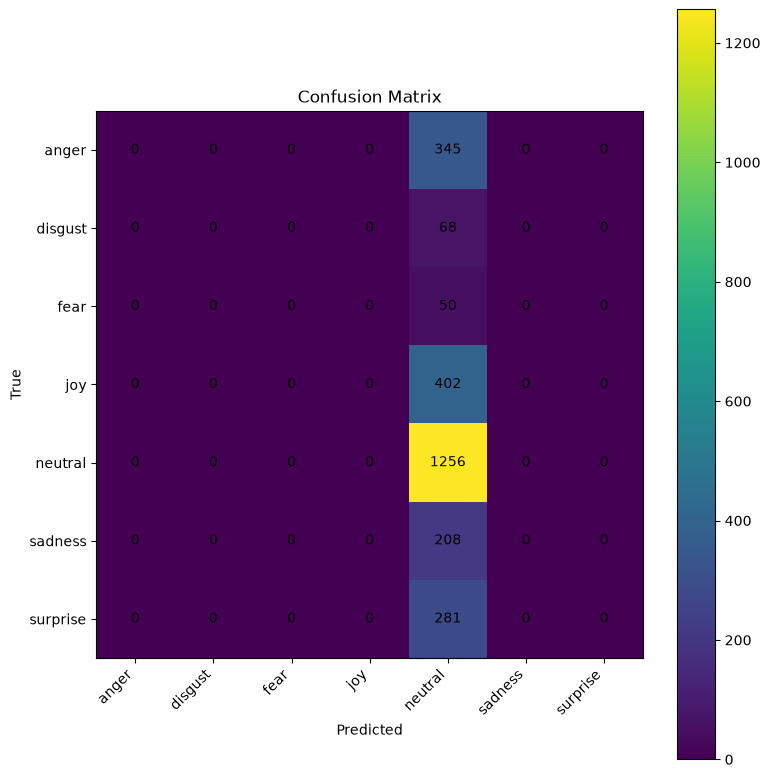

In [8]:
plot_confusion_matrix(results)

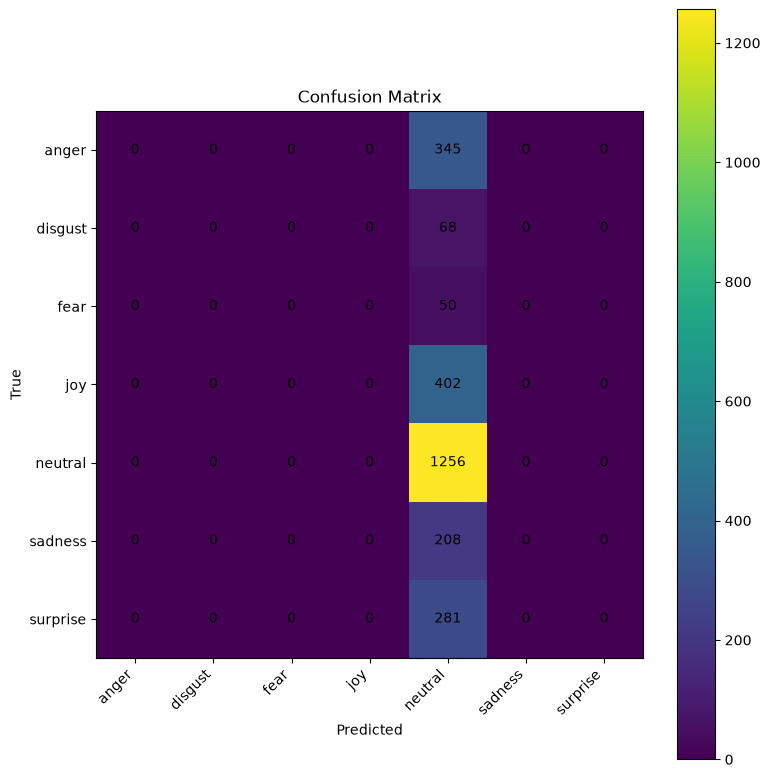

In [9]:
from src.config import FIGURES_DIR

plot_confusion_matrix(
    results,
    FIGURES_DIR / "majority_confusion_matrix.png",
)

In [10]:
save_metrics(
    results,
    "majority",
)

save_metadata(
    "majority",
    model="Majority Classifier",
    dataset="MELD",
)

save_confusion_matrix(
    results,
    "majority",
)